In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import BatchNormalization, Activation


In [32]:
(X_train,y_train),(X_test,y_test)= tf.keras.datasets.cifar10.load_data()

c:\Users\agasy\DeepLearning\DLEnv\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [33]:
print(f'training images', X_train.shape)
print(f'training labels', X_test.shape)

training images (50000, 32, 32, 3)
training labels (10000, 32, 32, 3)


In [34]:
print(f'traing data samples', len(X_train))
print(f'testing data sample', len(X_test))

traing data samples 50000
testing data sample 10000


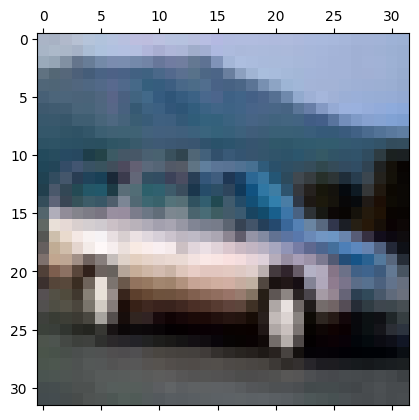

In [35]:
plt.matshow(X_train[4])

In [36]:
X_train.max(),X_train.min()

(np.uint8(255), np.uint8(0))

In [37]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

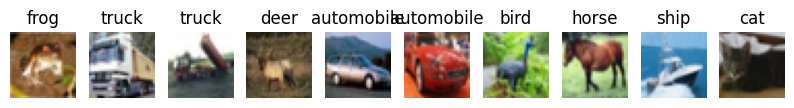

In [38]:
# Plot first 5 images
plt.figure(figsize=(10,2))
for i in range(10):
    plt.subplot(1,10,i+1)         # 1 row, 10 columns
    plt.imshow(X_train[i])        # pixel array
    plt.title(class_names[y_train[i][0]])  # label
    plt.axis('off')               # hide axes
plt.show()

## Normalization

In [39]:
for i in range(10):
    print(y_train[i])

[6]
[9]
[9]
[4]
[1]
[1]
[2]
[7]
[8]
[3]


In [40]:
X_train,X_test=X_train/255,X_test/255

In [42]:
for r in X_train[2]:
    print(r)


[[1.         1.         1.        ]
 [0.99215686 0.99215686 0.99215686]
 [0.99215686 0.99215686 0.99215686]
 [0.99215686 0.99215686 0.99215686]
 [0.99215686 0.99215686 0.99215686]
 [0.99215686 0.99215686 0.99215686]
 [0.99215686 0.99215686 0.99215686]
 [0.99215686 0.99215686 0.99215686]
 [0.99215686 0.99215686 0.99215686]
 [0.99215686 0.99215686 0.99215686]
 [0.99215686 0.99215686 0.99215686]
 [0.99215686 0.99215686 0.99215686]
 [0.99215686 0.99215686 0.99215686]
 [0.99215686 0.99215686 0.99215686]
 [0.99215686 0.98823529 0.99215686]
 [0.99607843 0.99215686 0.99607843]
 [0.96078431 0.94901961 0.95686275]
 [0.88627451 0.87843137 0.87843137]
 [0.95686275 0.94901961 0.94509804]
 [0.94509804 0.9254902  0.91372549]
 [0.98039216 0.96470588 0.95294118]
 [0.99215686 0.98823529 0.98039216]
 [0.98823529 0.99215686 0.98823529]
 [0.98039216 0.99215686 0.99215686]
 [0.99215686 0.99215686 0.99215686]
 [0.99215686 0.99215686 0.99215686]
 [0.99215686 0.99215686 0.99215686]
 [0.99215686 0.99215686 0.99

In [43]:
print(X_train.shape)

(50000, 32, 32, 3)


## Building CNN Model

In [51]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32,(3,3), activation='relu' ,padding='same', input_shape=(32,32,3)), 
    BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64,(3,3), activation='relu', padding='same'),
    BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    
    tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(), #converts 3d into map 1d vector ex. 8x8x128 = 8192 values

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5), #randomly disables 50% neurons to prevent overfitting

    tf.keras.layers.Dense(10, activation='softmax')  # Multi-class classification

])


model.summary()

c:\Users\agasy\DeepLearning\DLEnv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

## Compiling model

In [52]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

## Training model

In [53]:
History = model.fit(X_train,y_train, epochs=10, validation_data=(X_test,y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 43ms/step - accuracy: 0.4132 - loss: 1.6181 - val_accuracy: 0.5581 - val_loss: 1.2437
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 47s 30ms/step - accuracy: 0.5720 - loss: 1.2094 - val_accuracy: 0.6260 - val_loss: 1.0634
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.6367 - loss: 1.0396 - val_accuracy: 0.6436 - val_loss: 1.0588
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 57s 36ms/step - accuracy: 0.6815 - loss: 0.9222 - val_accuracy: 0.6935 - val_loss: 0.9196
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.7134 - loss: 0.8353 - val_accuracy: 0.7285 - val_loss: 0.7933
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.7371 - loss: 0.7591 - val_accuracy: 0.7123 - val_loss: 0.8579
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 63s 40ms/step - accuracy: 0.7595 - loss: 0.6966 - val_accuracy: 0.7364 - val_loss: 0.7778
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.7755 -

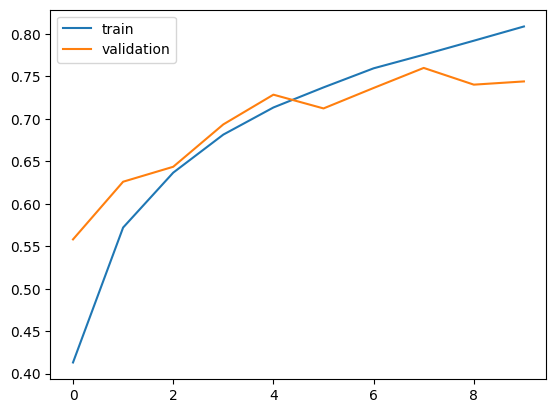

In [54]:
plt.plot(History.history['accuracy'])
plt.plot(History.history['val_accuracy'])
plt.legend(['train','validation'])
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


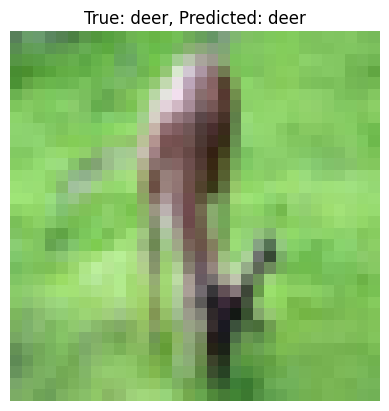

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


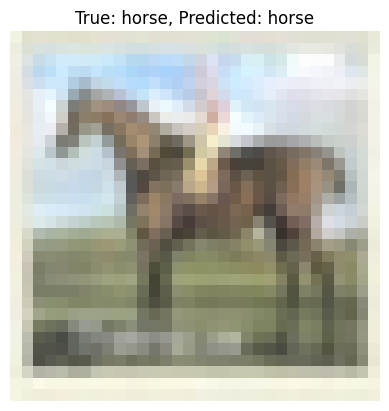

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


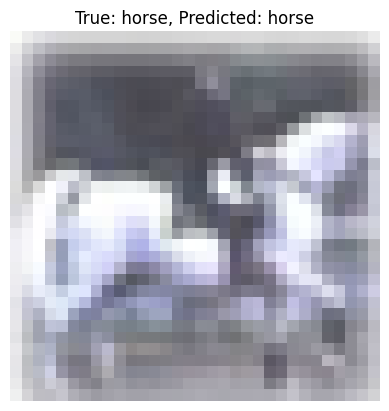

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


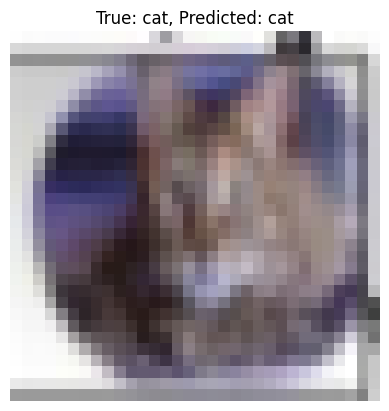

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


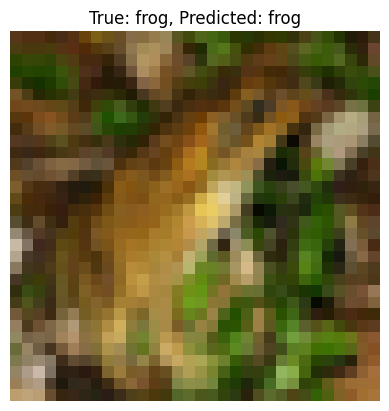

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


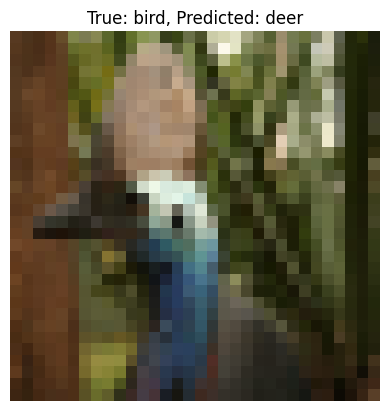

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


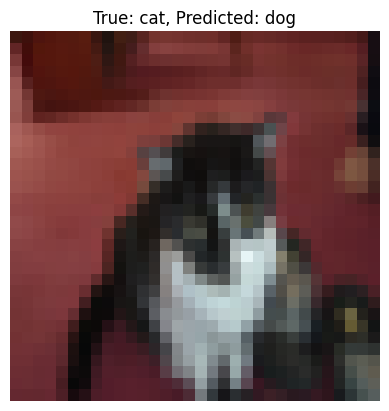

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


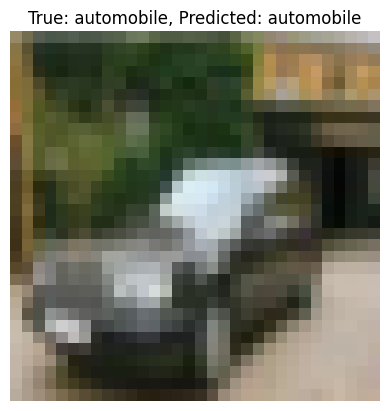

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


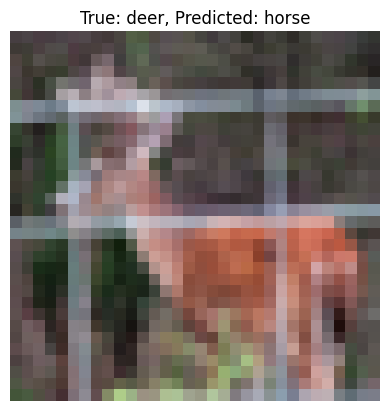

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


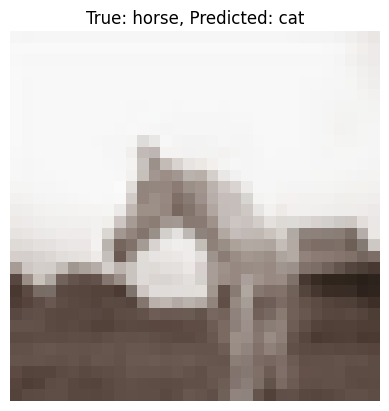

In [58]:
# Pick 5 random indices from test set
random_indices = np.random.choice(len(X_test), size=10, replace=False)

for i in random_indices:
    image = X_test[i]
    true_label = y_test[i][0]
    
    # Add batch dimension and predict
    prediction = model.predict(np.expand_dims(image, axis=0))
    predicted_label = np.argmax(prediction)
    
    # Plot the image with prediction
    plt.imshow(image)
    plt.title(f"True: {class_names[true_label]}, Predicted: {class_names[predicted_label]}")
    plt.axis('off')
    plt.show()